## [Kaggle Dataset](https://www.kaggle.com/datasets/denkuznetz/food-delivery-time-prediction)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')
df = pd.read_csv('data/Food_Delivery_Times.csv')

df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [2]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [3]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [4]:
print(df[df.isnull().any(axis=1)].shape) 

(117, 9)


In [5]:
df['Weather'] = df['Weather'].fillna('Clear')
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])


df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(-1)

In [6]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [20]:
df = df.drop(columns= 'Order_ID')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 1000 non-null   str    
 2   Traffic_Level           1000 non-null   str    
 3   Time_of_Day             1000 non-null   str    
 4   Vehicle_Type            1000 non-null   str    
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  1000 non-null   float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 83.7 KB


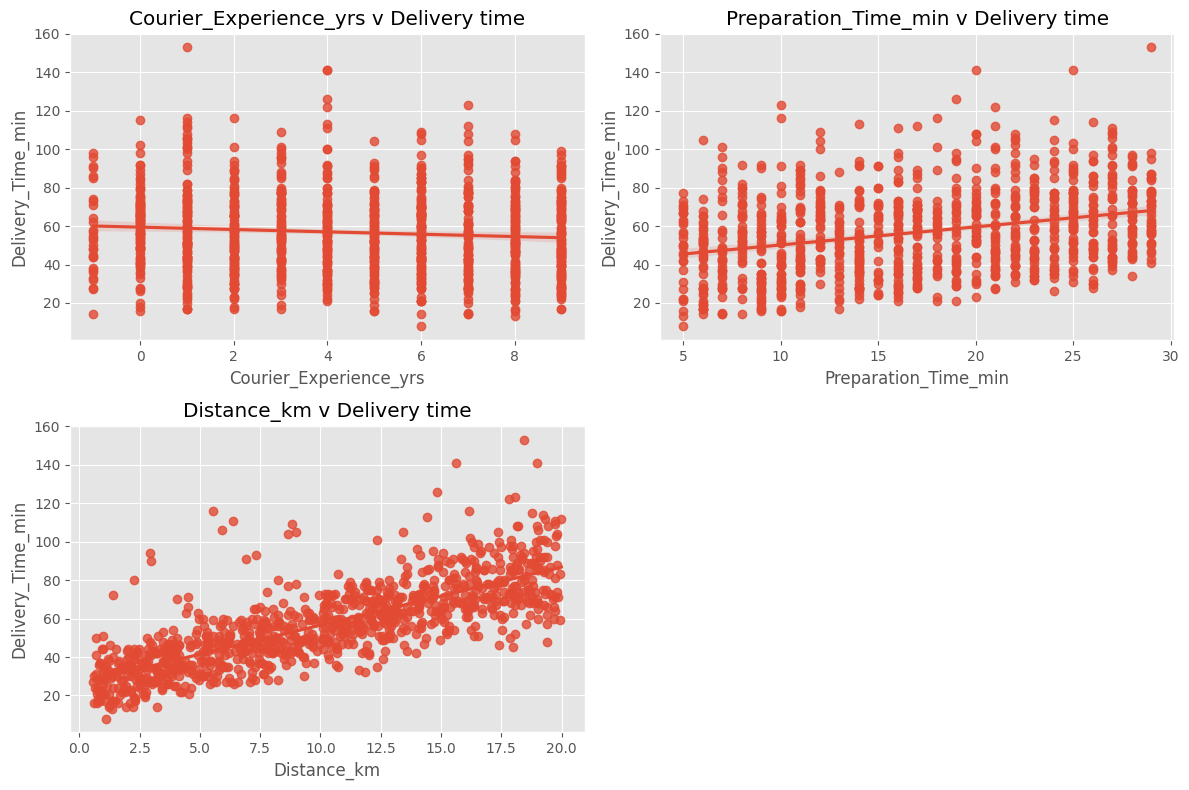

In [25]:
count_feature = ['Courier_Experience_yrs' , 'Preparation_Time_min',
                 'Distance_km'
                 ]


plt.figure(figsize= (12 ,8))
for count, col in enumerate(count_feature):
    plt.subplot(2, 2, count + 1)
    sns.regplot(df, x= col, y = 'Delivery_Time_min')
    plt.title(f'{col} v Delivery time')

plt.tight_layout()
plt.show()


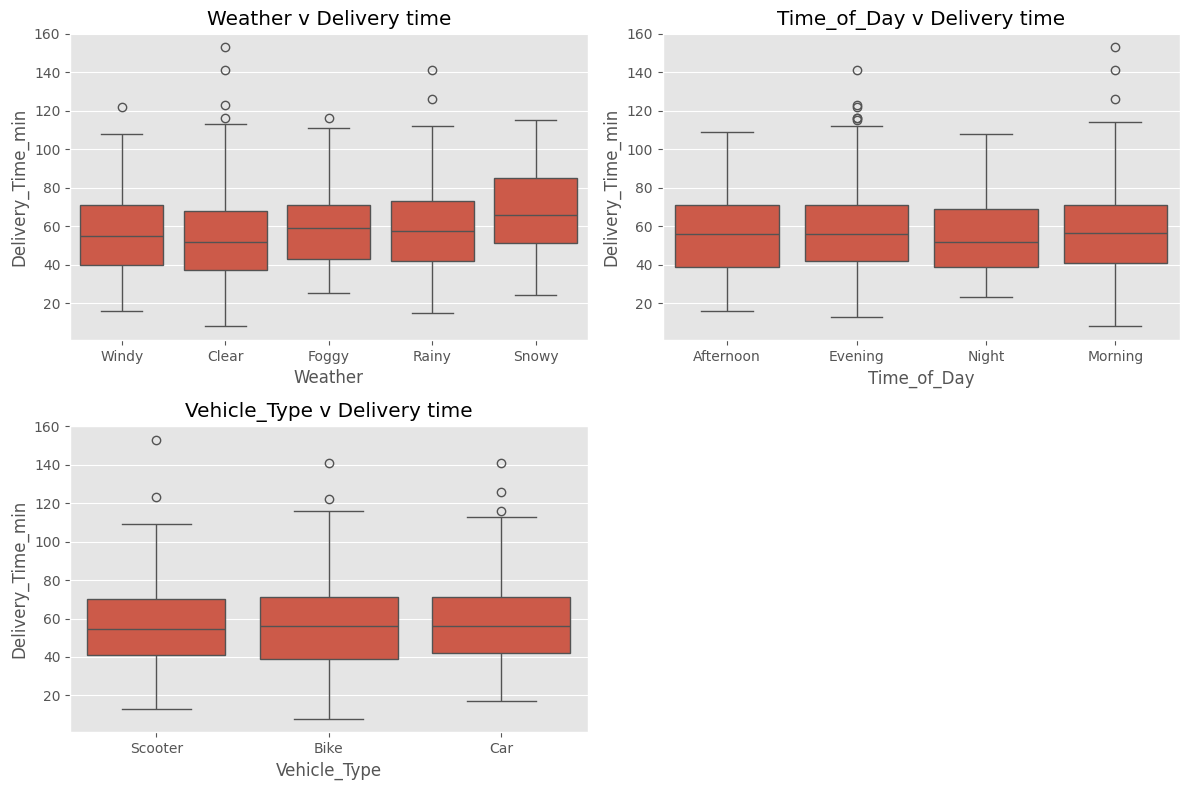

In [26]:
feature_type = ['Weather', 'Time_of_Day',
                'Vehicle_Type',]

plt.figure(figsize= (12 ,8))
for count, col in enumerate(feature_type):
    plt.subplot(2, 2, count + 1)
    sns.boxplot(df, y = 'Delivery_Time_min', x = col)
    plt.title(f"{col} v Delivery time")

plt.tight_layout()
plt.show()

In [27]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='str')

In [31]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()
df[['Weather', 'Traffic_Level', 'Vehicle_Type', 'Time_of_Day']] = oe.fit_transform(df[['Weather', 'Traffic_Level', 'Vehicle_Type', 'Time_of_Day']])



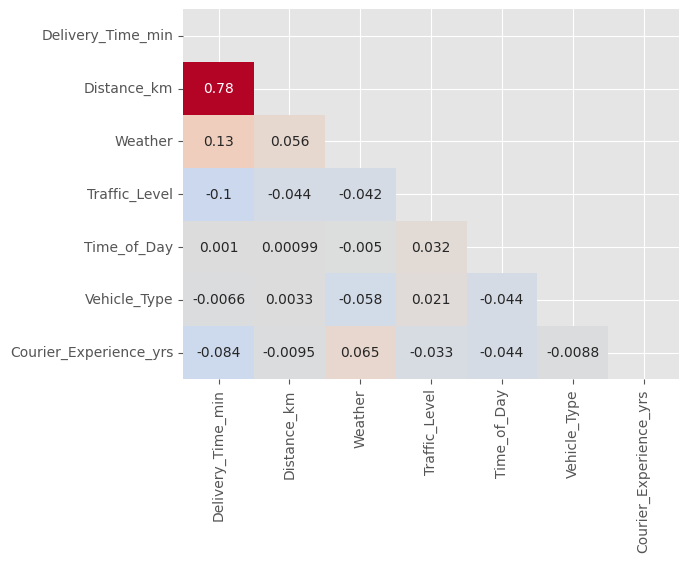

In [59]:
corr_feat = ['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 
       'Preparation_Time_min', 
       'Courier_Experience_yrs']

target = ['Delivery_Time_min']

matrix = df[target + corr_feat].corr()

mask = np.triu(np.ones_like(matrix, dtype= bool))

sns.heatmap(matrix, mask = mask, cmap = 'coolwarm', annot = True, center = 0,
            cbar = False)

plt.show()

We should not know `Preparation_time` when we make prediction

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

feature = ['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 
       # 'Preparation_Time_min', 
       'Courier_Experience_yrs']

X = df[feature].copy()
y = df[target].copy()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size= 0.7, random_state= 8)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size= 0.5, random_state= 8)

print(X_train.shape, X_val.shape, X_test.shape)

(700, 6) (150, 6) (150, 6)


In [65]:
models = {
    'base' : Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),
    'xgb' : XGBRegressor(n_estimators = 1000, random_state = 8, early_stopping_rounds = 50,
                         eval_metric = 'rmse')
}


for name, model in models.items():
    if name == 'xgb':
        model.fit(X_train, y_train,
                  eval_set = [(X_val, y_val)],
                  verbose = 100)
    else:
        model.fit(X_train, y_train)



[0]	validation_0-rmse:18.42467


[56]	validation_0-rmse:14.64582


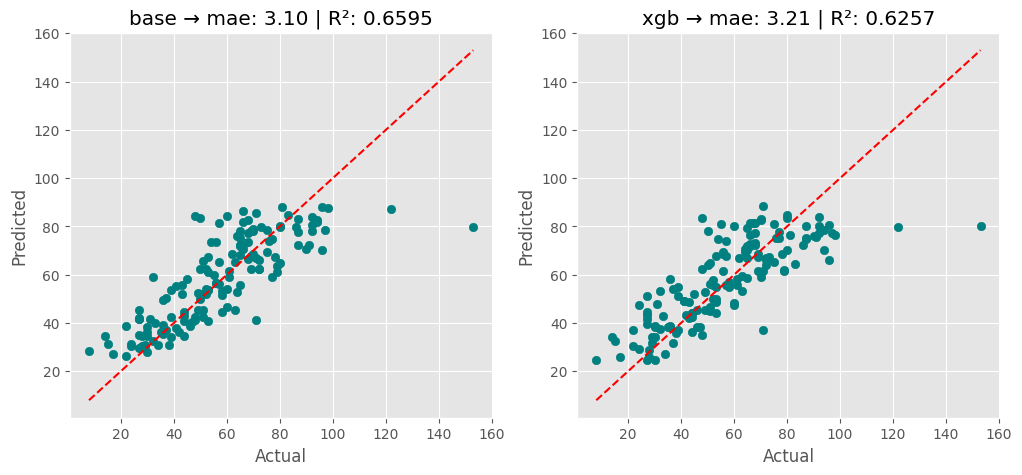

In [66]:
from sklearn.metrics import mean_absolute_error, r2_score


plt.figure(figsize= (12, 5))

for count, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_val)
    mae = np.sqrt(mean_absolute_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    plt.subplot(1, 2, count + 1)
    plt.scatter(x= y_val, y = y_pred, color = 'teal')
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{name} → mae: {mae:.2f} | R²: {r2:.4f}')

plt.show()

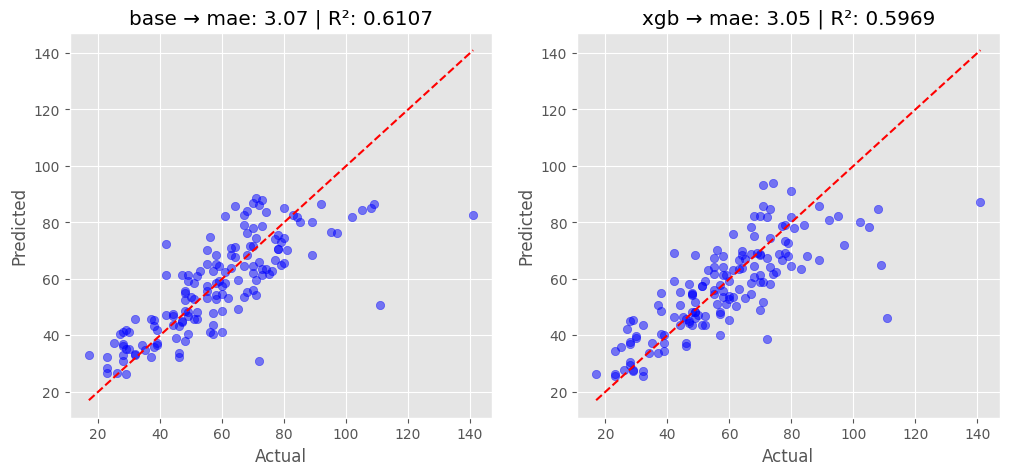

In [67]:

plt.figure(figsize= (12, 5))

for count, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    mae = np.sqrt(mean_absolute_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    plt.subplot(1, 2, count + 1)
    plt.scatter(x= y_test, y = y_pred, color = 'blue', alpha= 0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{name} → mae: {mae:.2f} | R²: {r2:.4f}')

plt.show()